 ICS553 Machine Learning Essentials(Group 4)
## Prosit 1: Data-Driven Allocation of Insecticide-Treated Nets in Ghana

 Objective

This notebook analyses district-level malaria case data and household survey data to
support a transparent and uncertainty-aware allocation of insecticide-treated nets (ITNs)
across Ghana.

The analysis focuses on two themes:

- **Theme A:** Statistical modelling of district-level malaria case counts and uncertainty.
- **Theme B:** Data availability, representation, preprocessing, and leakage assessment.

The analysis preserves the distinction between:

1. district-level malaria case counts used for statistical distribution modelling;
2. household-level survey data used to examine ITN coverage and sampling uncertainty.


In [41]:
#import libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")
# Load the CSV file into a DataFrame
district_df = pd.read_csv("ghana_district_cases.csv")
mis_df = pd.read_csv("ghana_mis_sample.csv")

print(f"District dataset: {district_df.shape[0]:,} rows × {district_df.shape[1]} columns")
print(f"MIS dataset:      {mis_df.shape[0]:,} rows × {mis_df.shape[1]} columns")



District dataset: 50 rows × 12 columns
MIS dataset:      17,933 rows × 10 columns


**Init Data Inventory**

In [42]:
# ============================================================
# 3. INITIAL DATA INVENTORY
# ============================================================

inventory = pd.DataFrame({
    "Dataset": ["District cases", "MIS household sample"],
    "Rows": [district_df.shape[0], mis_df.shape[0]],
    "Columns": [district_df.shape[1], mis_df.shape[1]],
    "Duplicate rows": [
        district_df.duplicated().sum(),
        mis_df.duplicated().sum()
    ],
    "Missing cells": [
        district_df.isna().sum().sum(),
        mis_df.isna().sum().sum()
    ]
})

display(inventory)

,Dataset,Rows,Columns,Duplicate rows,Missing cells
0,District cases,50,12,0,0
1,MIS household sample,17933,10,0,0


**Creating copies of the datasets for analysis**

In [43]:

district_analysis = district_df[
    [
        "district",
        "region_name",
        "region_code",
        "year_start",
        "year_end",
        "months_reported",
        "suspected_cases",
        "tested_cases",
        "positive_cases",
        "mean_population",
        "positive_per_100k",
        "net_coverage_pct"
    ]
].copy()

print("District analysis dataframe created.")



mis_analysis = mis_df[
    [
        "cluster",
        "household",
        "region",
        "residence",
        "sample_weight",
        "wealth_index",
        "has_net",
        "num_nets",
        "children_under_net_last_night",
        "eligible_children"
    ]
].copy()

print("MIS analysis dataframe created.")



District analysis dataframe created.
MIS analysis dataframe created.


Check data types 

In [44]:
print("District data types:")
display(
    district_analysis.dtypes.rename("dtype").to_frame()
)

print("\nMIS data types:")
display(
    mis_analysis.dtypes.rename("dtype").to_frame()
)

District data types:


,dtype
district,str
region_name,str
region_code,int64
year_start,int64
year_end,int64
months_reported,int64
suspected_cases,int64
tested_cases,int64
positive_cases,int64
mean_population,float64



MIS data types:


,dtype
cluster,int64
household,int64
region,int64
residence,str
sample_weight,float64
wealth_index,int64
has_net,int64
num_nets,int64
children_under_net_last_night,int64
eligible_children,int64


In [45]:

# 8. DATA QUALITY CHECKS

quality_checks = pd.DataFrame({
    "Check": [
        "Negative positive cases",
        "Negative tested cases",
        "Positive cases > tested cases",
        "Tested cases > suspected cases",
        "Negative population",
        "ITN coverage outside 0-100%"
    ],
    "Count": [
        (district_analysis["positive_cases"] < 0).sum(),
        (district_analysis["tested_cases"] < 0).sum(),
        (
            district_analysis["positive_cases"]
            > district_analysis["tested_cases"]
        ).sum(),
        (
            district_analysis["tested_cases"]
            > district_analysis["suspected_cases"]
        ).sum(),
        (district_analysis["mean_population"] <= 0).sum(),
        (
            (district_analysis["net_coverage_pct"] < 0)
            | (district_analysis["net_coverage_pct"] > 100)
        ).sum()
    ]
})

display(quality_checks)




# ============================================================
# 9. MIS DATA QUALITY CHECKS
# ============================================================

mis_quality = pd.DataFrame({
    "Check": [
        "Non-positive sample weights",
        "Negative number of nets",
        "Negative eligible children",
        "Children under net > eligible children",
        "Invalid has_net values"
    ],
    "Count": [
        (mis_analysis["sample_weight"] <= 0).sum(),
        (mis_analysis["num_nets"] < 0).sum(),
        (mis_analysis["eligible_children"] < 0).sum(),
        (
            mis_analysis["children_under_net_last_night"]
            > mis_analysis["eligible_children"] #take a look at this line
            
        ).sum(),
        (~mis_analysis["has_net"].isin([0, 1])).sum()
    ]
})

display(mis_quality)

,Check,Count
0,Negative positive cases,0
1,Negative tested cases,0
2,Positive cases > tested cases,0
3,Tested cases > suspected cases,0
4,Negative population,0
5,ITN coverage outside 0-100%,0


,Check,Count
0,Non-positive sample weights,0
1,Negative number of nets,0
2,Negative eligible children,0
3,Children under net > eligible children,1859
4,Invalid has_net values,0


## Preprocessing decision

Preprocessing is performed according to the purpose of each variable.

The district-level `positive_cases` variable is a count and is therefore retained in
its original scale for Poisson and Negative Binomial modelling. Standardising or
normalising this variable would change the quantity being modelled.

The `positive_per_100k` variable is retained as a rate for interpretation and comparison,
but it will not be used as a predictor of `positive_cases` because it is mathematically
derived from the outcome and population.

Identifiers such as `district`, `household`, and `cluster` are retained for grouping,
sampling, and interpretation rather than being treated automatically as numerical
features.

If a predictive model requires numerical scaling or categorical encoding, those
transformations will be fitted only on the training data using a preprocessing pipeline.

**Theme B
Data Availability and Representation**

In [46]:
region_summary = (
    mis_analysis
    .groupby("region")
    .agg(
        households=("household", "nunique"),
        clusters=("cluster", "nunique"),
        rural_pct=(
            "residence",
            lambda x: (x.astype(str).str.lower() == "rural").mean() * 100
        )
    )
    .reset_index()
)

display(region_summary)


# ============================================================
# CHECK RESIDENCE CATEGORIES
# ============================================================

print("Residence categories:")
display(
    mis_analysis["residence"]
    .value_counts(dropna=False)
    .to_frame("count")
)

,region,households,clusters,rural_pct
0,1,264,37,48.298068
1,2,245,40,45.172414
2,3,245,48,18.529200
3,4,205,37,54.713494
4,5,230,41,48.930921
5,6,236,48,42.018611
6,7,240,37,62.488219
7,8,243,36,49.905838
8,9,222,36,44.271845
9,10,224,36,47.153700


Residence categories:


,count
residence,
rural,9138
urban,8795


**Cluster Represemtation**

In [47]:
cluster_summary = (
    mis_analysis
    .groupby("region")
    .agg(
        households=("household", "nunique"),
        clusters=("cluster", "nunique")
    )
    .reset_index()
)

cluster_summary["households_per_cluster"] = (
    cluster_summary["households"]
    / cluster_summary["clusters"]
)

display(
    cluster_summary.round(2)
)

,region,households,clusters,households_per_cluster
0,1,264,37,7.14
1,2,245,40,6.12
2,3,245,48,5.10
3,4,205,37,5.54
4,5,230,41,5.61
5,6,236,48,4.92
6,7,240,37,6.49
7,8,243,36,6.75
8,9,222,36,6.17
9,10,224,36,6.22


**ITN coverage per region**

,region,households,ownership_pct,mean_nets
0,1,264,64.31,1.50
1,2,245,67.59,1.71
2,3,245,50.68,1.07
3,4,205,82.35,1.99
4,5,230,70.48,1.63
5,6,236,66.07,1.62
6,7,240,76.44,1.84
7,8,243,79.66,2.08
8,9,222,72.91,1.67
9,10,224,76.28,1.87


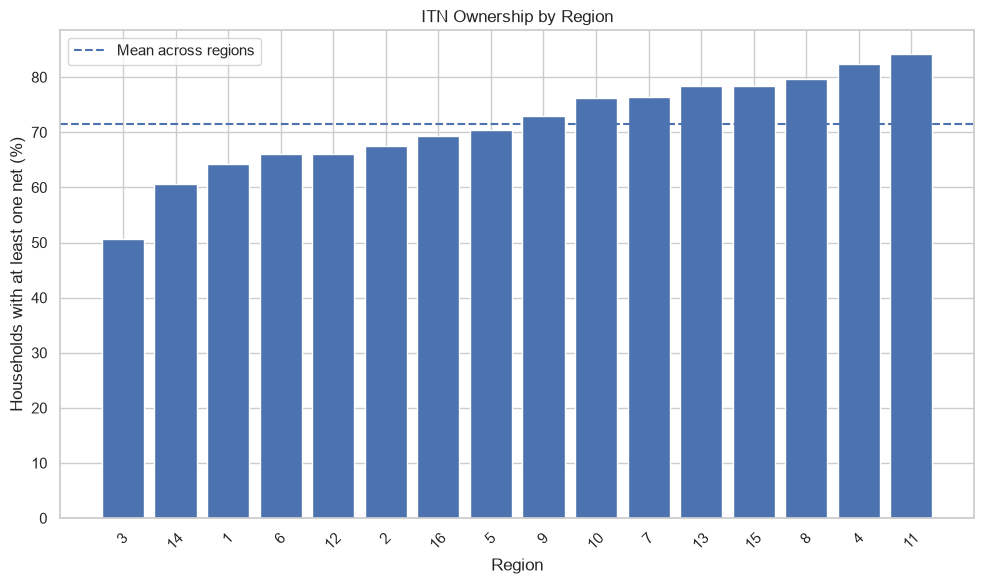

,region,households,ownership_pct,mean_nets
2,3,245,50.68,1.07
13,14,191,60.54,1.26
0,1,264,64.31,1.50
5,6,236,66.07,1.62
11,12,182,66.14,1.59
1,2,245,67.59,1.71
15,16,180,69.37,1.34
4,5,230,70.48,1.63
8,9,222,72.91,1.67
9,10,224,76.28,1.87


In [48]:

itn_summary = (
    mis_analysis
    .groupby("region")
    .agg(
        households=("household", "nunique"),
        ownership_pct=("has_net", "mean"),
        mean_nets=("num_nets", "mean")
    )
    .reset_index()
)

itn_summary["ownership_pct"] *= 100

display(
    itn_summary.round(2)
)

plot_data = itn_summary.sort_values(
    "ownership_pct"
)

plt.figure(figsize=(10, 6))

plt.bar(
    plot_data["region"].astype(str),
    plot_data["ownership_pct"]
)

plt.axhline(
    plot_data["ownership_pct"].mean(),
    linestyle="--",
    label="Mean across regions"
)

plt.xlabel("Region")
plt.ylabel("Households with at least one net (%)")
plt.title("ITN Ownership by Region")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

#added part
itn_summary_sorted = itn_summary.sort_values(
    "ownership_pct"
)

display(
    itn_summary_sorted[
        ["region", "households", "ownership_pct", "mean_nets"]
    ].round(2)
)

**District-Level Malaria Burden**

In [49]:
district_burden = district_analysis[
    [
        "district",
        "region_name",
        "positive_cases",
        "mean_population",
        "positive_per_100k",
        "net_coverage_pct"
    ]
].copy()

display(
    district_burden.sort_values(
        "positive_cases",
        ascending=False
    ).head(20)
)

,district,region_name,positive_cases,mean_population,positive_per_100k,net_coverage_pct
4,Bolgatanga,Upper East Region,589849,146647.9,402221.14,79.56
14,Garu-Tempane,Upper East Region,537743,144084.4,373213.98,79.56
43,Wa,Upper West Region,510536,119409.3,427551.41,69.76
0,Bawku,Upper East Region,375349,109220.3,343662.30,79.56
5,Bongo,Upper East Region,332006,94019.1,353126.26,79.56
19,Kasena-Nankana West,Upper East Region,331779,78846.7,420790.17,79.56
1,Bawku West,Upper East Region,330111,104485.8,315938.62,79.56
32,Pusiga,Upper East Region,324040,63912.7,507004.33,79.56
16,Jirapa,Upper West Region,295356,98366.3,300261.35,69.76
18,Kasena-Nankana,Upper East Region,279555,121967.0,229205.53,79.56


**Distribution of Positive Cases**

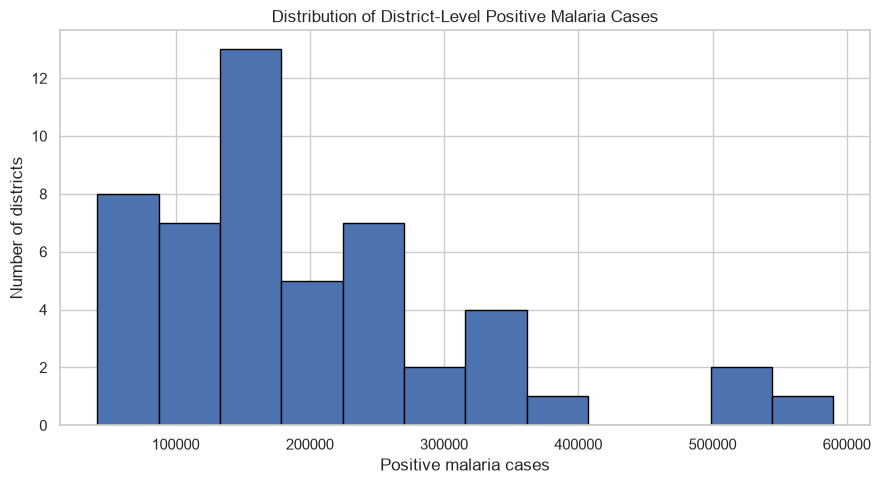

In [50]:
plt.figure(figsize=(9, 5))

plt.hist(
    district_analysis["positive_cases"],
    bins=12,
    edgecolor="black"
)

plt.xlabel("Positive malaria cases")
plt.ylabel("Number of districts")
plt.title("Distribution of District-Level Positive Malaria Cases")

plt.tight_layout()
plt.show()

*Theme A* **Poisson Fitting**

In [51]:
positive_cases = district_analysis["positive_cases"]

count_mean = positive_cases.mean()
count_variance = positive_cases.var()
dispersion_ratio = count_variance / count_mean

distribution_summary = pd.DataFrame({
    "Statistic": [
        "Number of districts",
        "Mean",
        "Variance",
        "Standard deviation",
        "Variance / Mean"
    ],
    "Value": [
        len(positive_cases),
        count_mean,
        count_variance,
        positive_cases.std(),
        dispersion_ratio
    ]
})

display(distribution_summary.round(2))

,Statistic,Value
0,Number of districts,5.000000e+01
1,Mean,1.956396e+05
2,Variance,1.510000e+10
3,Standard deviation,1.228821e+05
4,Variance / Mean,7.718275e+04


In [52]:
from scipy.stats import poisson

lambda_poisson = positive_cases.mean()

print(f"Estimated Poisson λ: {lambda_poisson:,.2f}")

Estimated Poisson λ: 195,639.62


In [82]:

"""
x_values = np.arange(
    positive_cases.min(),
    positive_cases.max() + 1
)

# The values are extremely large, so plotting every integer
# is unnecessary. Use a compact support for visual comparison.
x_grid = np.linspace(
    positive_cases.min(),
    positive_cases.max(),
    300
)

# Approximate Poisson density using the normal approximation
# for visualization at this very large count scale.
from scipy.stats import norm

poisson_approx = norm.pdf(
    x_grid,
    loc=lambda_poisson,
    scale=np.sqrt(lambda_poisson)
)

plt.figure(figsize=(9, 5))

plt.hist(
    positive_cases,
    bins=12,
    density=True,
    alpha=0.6,
    edgecolor="black",
    label="Observed district counts"
)

plt.plot(
    x_grid,
    poisson_approx,
    linewidth=2,
    label="Poisson fitted shape"
)

plt.xlabel("Positive malaria cases")
plt.ylabel("Density")
plt.title("Observed Positive Cases vs Poisson Fitted Shape")
plt.legend()
plt.tight_layout()
plt.show()
"""


'\nx_values = np.arange(\n    positive_cases.min(),\n    positive_cases.max() + 1\n)\n\n# The values are extremely large, so plotting every integer\n# is unnecessary. Use a compact support for visual comparison.\nx_grid = np.linspace(\n    positive_cases.min(),\n    positive_cases.max(),\n    300\n)\n\n# Approximate Poisson density using the normal approximation\n# for visualization at this very large count scale.\nfrom scipy.stats import norm\n\npoisson_approx = norm.pdf(\n    x_grid,\n    loc=lambda_poisson,\n    scale=np.sqrt(lambda_poisson)\n)\n\nplt.figure(figsize=(9, 5))\n\nplt.hist(\n    positive_cases,\n    bins=12,\n    density=True,\n    alpha=0.6,\n    edgecolor="black",\n    label="Observed district counts"\n)\n\nplt.plot(\n    x_grid,\n    poisson_approx,\n    linewidth=2,\n    label="Poisson fitted shape"\n)\n\nplt.xlabel("Positive malaria cases")\nplt.ylabel("Density")\nplt.title("Observed Positive Cases vs Poisson Fitted Shape")\nplt.legend()\nplt.tight_layout()\nplt.sh

In [54]:


if dispersion_ratio <= 1.2:
    interpretation = "Variance is relatively close to the mean."
else:
    interpretation = "Variance substantially exceeds the mean, indicating overdispersion."

poisson_diagnostic = pd.DataFrame({
    "Metric": [
        "Poisson lambda",
        "Observed mean",
        "Observed variance",
        "Variance / mean",
        "Interpretation"
    ],
    "Value": [
        lambda_poisson,
        count_mean,
        count_variance,
        dispersion_ratio,
        interpretation
    ]
})

display(poisson_diagnostic)

,Metric,Value
0,Poisson lambda,195639.62
1,Observed mean,195639.62
2,Observed variance,15100003891.505718
3,Variance / mean,77182.750056
4,Interpretation,"Variance substantially exceeds the mean, indic..."


**Negative Binomial Model**

In [ ]:
#!pip install statsmodels #uncomment this line if you haven't installed statsmodels yet

import statsmodels.api as sm

nb_model = sm.NegativeBinomial(
    positive_cases,
    np.ones(len(positive_cases))
)

nb_results = nb_model.fit(
    disp=False
)

print(nb_results.summary())

                     NegativeBinomial Regression Results                      
Dep. Variable:         positive_cases   No. Observations:                   50
Model:               NegativeBinomial   Df Residuals:                       49
Method:                           MLE   Df Model:                            0
Date:                Mon, 21 Sep 2026   Pseudo R-squ.:              -1.123e-11
Time:                        12:49:17   Log-Likelihood:                -647.10
converged:                       True   LL-Null:                       -647.10
Covariance Type:            nonrobust   LLR p-value:                       nan
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.1840      0.083    147.406      0.000      12.022      12.346
alpha          0.3416      0.065      5.271      0.000       0.215       0.469


In [56]:
nb_params = nb_results.params

nb_summary = pd.DataFrame({
    "Parameter": nb_params.index,
    "Estimate": nb_params.values
})

display(nb_summary.round(4))

,Parameter,Estimate
0,const,12.1840
1,alpha,0.3416


In [83]:
"""# The count variable we are modelling
x = district_analysis["positive_cases"].dropna()

print("Number of observations:", len(x))
print("Minimum:", x.min())
print("Maximum:", x.max())
print("Mean:", x.mean())
print("Variance:", x.var())
print("Standard deviation:", x.std())

print("\nFirst 10 observations:")
print(x.head(10).to_string(index=False))
"""

'# The count variable we are modelling\nx = district_analysis["positive_cases"].dropna()\n\nprint("Number of observations:", len(x))\nprint("Minimum:", x.min())\nprint("Maximum:", x.max())\nprint("Mean:", x.mean())\nprint("Variance:", x.var())\nprint("Standard deviation:", x.std())\n\nprint("\nFirst 10 observations:")\nprint(x.head(10).to_string(index=False))\n'

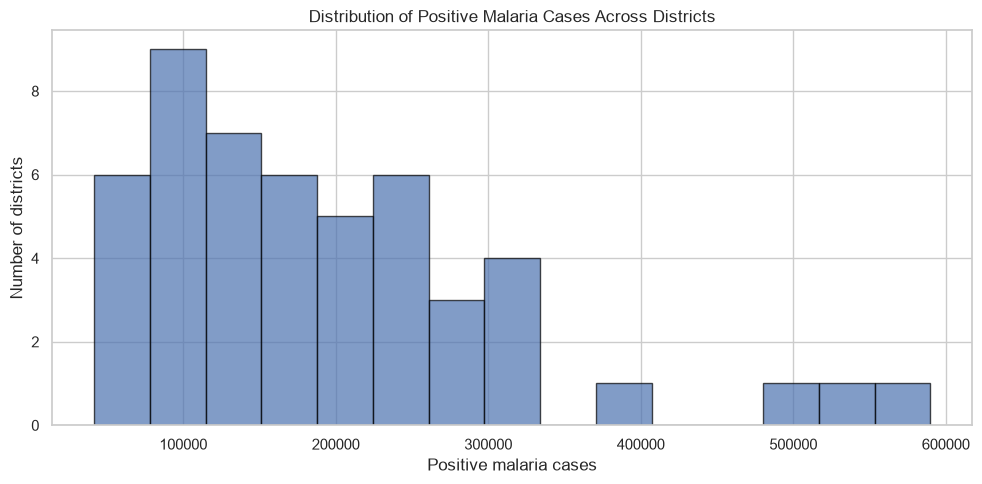

In [59]:
plt.figure(figsize=(10, 5))

plt.hist(
    x,
    bins=15,
    edgecolor="black",
    alpha=0.7
)

plt.xlabel("Positive malaria cases")
plt.ylabel("Number of districts")
plt.title("Distribution of Positive Malaria Cases Across Districts")

plt.tight_layout()
plt.show()

In [64]:
# Poisson parameter
lambda_hat = x.mean()

print(f"Estimated Poisson λ = {lambda_hat:,.2f}")



Estimated Poisson λ = 195,639.62


In [66]:
# Integer values corresponding to observed count range
from scipy import stats
k = np.arange(
    int(x.min()),
    int(x.max()) + 1
)

poisson_pmf = stats.poisson.pmf(k, mu=lambda_hat)

Poisson λ = 195,639.62
Negative Binomial r = 2.5348
Negative Binomial p = 0.00001296


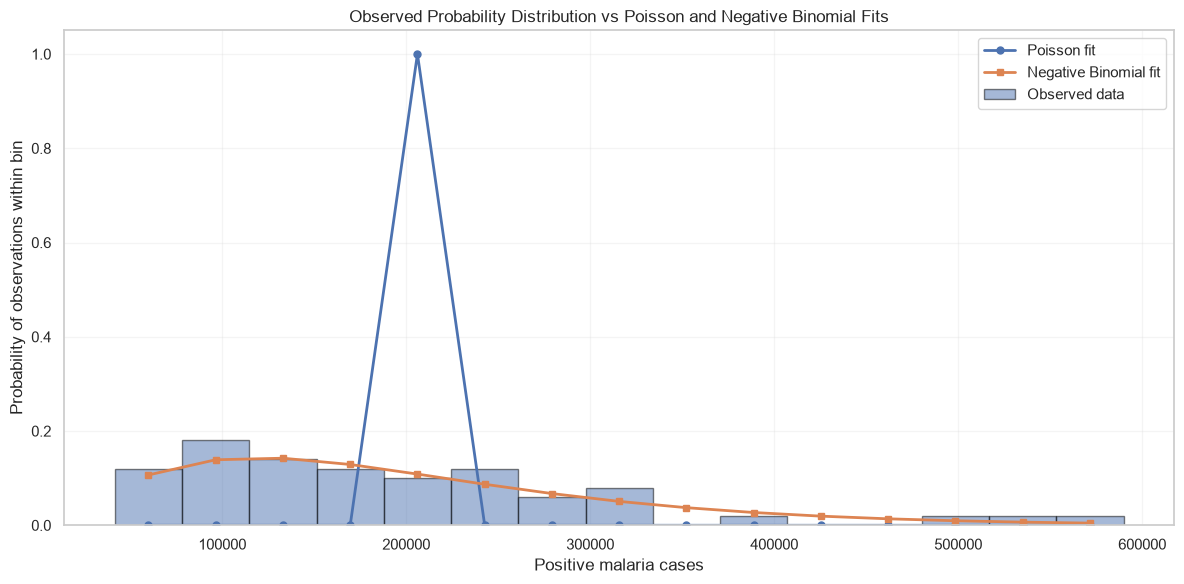

: 

In [ ]:
"""import numpy as np
import matplotlib.pyplot as plt
from scipy import stats"""

# ---------------------------------------------------------
# DATA
# ---------------------------------------------------------
x = district_analysis["positive_cases"].dropna().astype(int).values

# ---------------------------------------------------------
# FIT POISSON
# ---------------------------------------------------------
lambda_hat = x.mean()

# ---------------------------------------------------------
# FIT NEGATIVE BINOMIAL
# Method of moments
# ---------------------------------------------------------
mu = x.mean()
variance = x.var(ddof=1)

if variance <= mu:
    raise ValueError(
        "Variance is not greater than the mean, so the "
        "Negative Binomial overdispersion estimate is invalid."
    )

r_hat = mu**2 / (variance - mu)
p_hat = r_hat / (r_hat + mu)

print(f"Poisson λ = {lambda_hat:,.2f}")
print(f"Negative Binomial r = {r_hat:,.4f}")
print(f"Negative Binomial p = {p_hat:.8f}")

# ---------------------------------------------------------
# HISTOGRAM BINS
# ---------------------------------------------------------
n_bins = 15

counts, bin_edges = np.histogram(
    x,
    bins=n_bins
)

# Convert counts into probabilities
bin_probabilities = counts / len(x)

# Bin centers for plotting
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# ---------------------------------------------------------
# CALCULATE DISTRIBUTION PROBABILITY WITHIN EACH BIN
# ---------------------------------------------------------
poisson_bin_probs = []
nb_bin_probs = []

for lower, upper in zip(bin_edges[:-1], bin_edges[1:]):

    # Integer values belonging to this bin
    k_values = np.arange(
        int(np.ceil(lower)),
        int(np.ceil(upper))
    )

    # Poisson probability within bin
    poisson_prob = stats.poisson.pmf(
        k_values,
        mu=lambda_hat
    ).sum()

    # Negative Binomial probability within bin
    nb_prob = stats.nbinom.pmf(
        k_values,
        n=r_hat,
        p=p_hat
    ).sum()

    poisson_bin_probs.append(poisson_prob)
    nb_bin_probs.append(nb_prob)

poisson_bin_probs = np.array(poisson_bin_probs)
nb_bin_probs = np.array(nb_bin_probs)

# ---------------------------------------------------------
# PLOT
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

# Observed probability per bin
plt.bar(
    bin_centers,
    bin_probabilities,
    width=np.diff(bin_edges),
    alpha=0.5,
    edgecolor="black",
    label="Observed data"
)

# Poisson
plt.plot(
    bin_centers,
    poisson_bin_probs,
    marker="o",
    linewidth=2,
    markersize=5,
    label="Poisson fit"
)

# Negative Binomial
plt.plot(
    bin_centers,
    nb_bin_probs,
    marker="s",
    linewidth=2,
    markersize=5,
    label="Negative Binomial fit"
)

plt.xlabel("Positive malaria cases")
plt.ylabel("Probability of observations within bin")
plt.title(
    "Observed Probability Distribution vs Poisson and Negative Binomial Fits"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [77]:
# Compare mean and variance
mean_x = x.mean()
variance_x = x.var(ddof=1)

print("Mean:", f"{mean_x:,.2f}")
print("Variance:", f"{variance_x:,.2f}")
print("Variance / Mean:", f"{variance_x / mean_x:,.2f}")

Mean: 195,639.62
Variance: 15,100,003,891.51
Variance / Mean: 77,182.75
